In [1]:
import os
os.chdir('/Users/marindeniaud/PhD/PhD-git/luxe-elbex')

import numpy as _np
import matplotlib.pyplot as _plt
import pybdsim as _bd

import plotXsuite
from scipy.special import erf

from manchester_farm.background import beamGas

initializing ocelot...


In [2]:
def plotExpectedHits(xsuite, linename, gmadfilename, histfilename=None, gmadfolder='gmad_files/',
                     emitx=3.58e-11, emity=3.58e-11, esprd=2e-6,
                     pipe_radius=0.02413, ngen=500_000,
                     xlabel=True, xlim=None, ylim=None, lattice=True, figsize=[12, 3]):
    line = xsuite.env.lines[linename]
    tws0 = xsuite.tws0
    s0 = xsuite.s0
    _plt.figure(figsize=figsize)
    tw = line.twiss(**tws0)
    E0 = tw.particle_on_co.p0c.base
    sigx = _np.sqrt(tw.betx * emitx + tw.dx ** 2 * (esprd / E0) ** 2)
    sigy = _np.sqrt(tw.bety * emity + tw.dy ** 2 * (esprd / E0) ** 2)

    n_sigma_x = pipe_radius / sigx
    n_sigma_y = pipe_radius / sigy

    proba_x = 0.5*(1 - erf(n_sigma_x / _np.sqrt(2)))
    proba_y = 0.5*(1 - erf(n_sigma_y / _np.sqrt(2)))

    hit_x = proba_x * ngen
    hit_y = proba_y * ngen
    hits = hit_x + hit_y
    
    if histfilename is not None:
        histfile = _bd.Data.Load(histfilename)
        hist = histfile.histogramspy["Event/MergedHistograms/" + 'PFH_S_all']
        beamGas.plotHistogram(histfilename, "PFH_S_all", gmadfile=None, samefig=True, s0=s0, label='PFH_S_all : {} hits'.format(hist.entries))
    _plt.hist(tw.s + s0, bins=200, weights=hits, histtype='step', color="C1", label=r'Expected : {:.2f} hits'.format(sum(hits)))
    # _plt.plot(tw.s + s0, hits, ls='', marker='+', markersize=10, color='C1', label=r'Expected hits')
    

    _plt.ylabel(r'$N_{{hit}}$')
    if xlabel:
        _plt.xlabel(r'$s$ [m]')
    _plt.grid(True)
    _plt.legend(loc='upper right')
    _plt.ylim(ylim)
    if lattice:
        plotXsuite.addMachineLattice(xsuite, linename, gmadfilename, gmadfolder)
    _plt.xlim(xlim)

In [3]:
from xsuite_scripts import XTD8_no_DBA_match_with_no_R56 as XTD8_matched_Xsuite

In [35]:
mergedhistfile = "manchester_farm/background/results/mergedfiles/445000_part_XTD8_halo_4.5-5.5_emit_2.5e-7_merged.root"

REBDSIMCOMBINE analysis file - using RebdsimFile
REBDSIMCOMBINE analysis file - using RebdsimFile
BDSIM output file - using DataLoader
BDSIM output file - using DataLoader


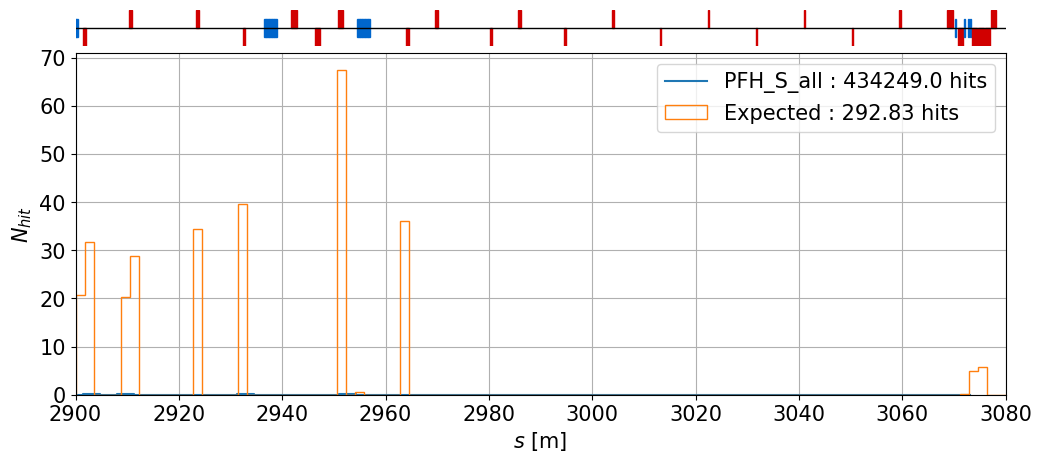

In [36]:
plotExpectedHits(XTD8_matched_Xsuite, 'XTD8', "XTD8_matched_biasing", mergedhistfile,
                 emitx=2.5e-7, emity=2.5e-7, esprd=0, 
                 figsize=[12, 5], lattice=True, 
                 # xlim=[2900, 2970]
                 xlim=[2900, 3080]
                )

REBDSIMCOMBINE analysis file - using RebdsimFile


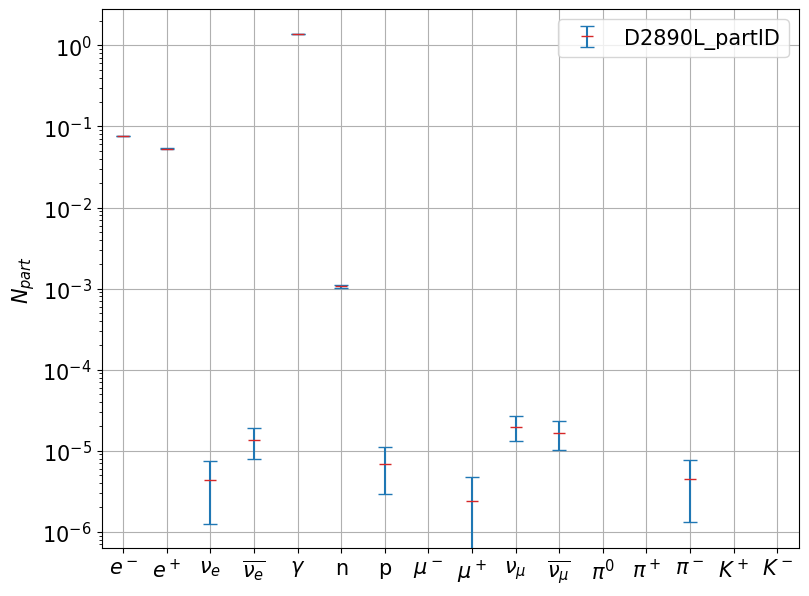

In [37]:
beamGas.plotHistogram(mergedhistfile, "D2890L_partID",
                      errorbars=True, partlabels=True, logY=True, xlim=[0.5, 16.5], samefig=False, 
                      figsize=[9, 7])
# _plt.ylim(1e-2, 1e3);

In [38]:
beamGas.checkSpeciesAtSampler(mergedhistfile)

REBDSIMCOMBINE analysis file - using RebdsimFile
['all'] 667393.0
['electron'] 43641.0
['photon'] 600419.0
['positron'] 22841.0
['neutron'] 462.0
['proton'] 3.0
['muon', 'neutrino'] 9.0
['electron', 'neutrino'] 2.0
['muon', 'anti', 'neutrino'] 7.0
['pion', 'minus'] 2.0
['pion', 'plus'] 0.0
['anti', 'muon'] 1.0
['electron', 'anti', 'neutrino'] 6.0
['muon'] 0.0


In [8]:
def calcHowMuchSigma(pipe_radius = 0.02413, emittance=2e-7, beta=160, disp=-2, sigmaE=0.0006, E0=17.5):
    sigma = _np.sqrt(beta*emittance + disp**2 * sigmaE**2 / E0**2)
    return pipe_radius / sigma

def estimateHits(primaries=100_000, pipe_radius = 0.02413, emittance=2e-7, beta=160, disp=-2, sigmaE=0.0006, E0=17.5):
    # get at how much sigma is the beam pipe
    n_sigma = calcHowMuchSigma(pipe_radius, emittance, beta, disp, sigmaE, E0)
    
    # get the probability of a particle ot be hitting th pipe
    proba = 1 - erf(n_sigma/_np.sqrt(2))
    
    return proba * primaries

In [13]:
calcHowMuchSigma(pipe_radius = 0.02413, emittance=2.5e-7, beta=160, disp=0, sigmaE=0, E0=17.5)

np.float64(3.8152879969931495)

BDSIM output file - using DataLoader
BDSIM output file - using DataLoader


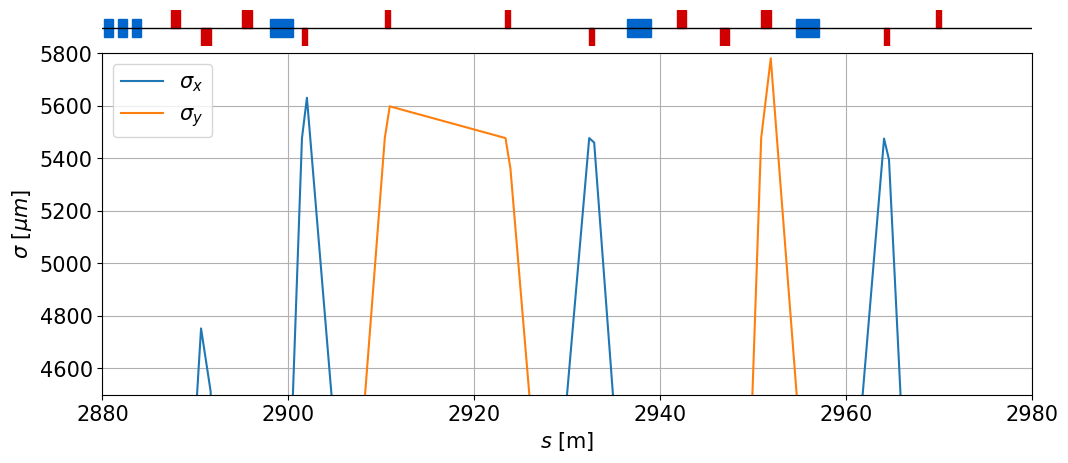

In [21]:
plotXsuite.plotSigma(XTD8_matched_Xsuite, 'XTD8', "XTD8_matched_biasing", emitx=2e-7, emity=2e-7, esprd=0, 
                     figsize=[12, 5], lattice=True, markers=False, xlim=[2880, 2980], ylim=[4500, 5800])
# _plt.axhline(0.02413*2*1e6, ls='--', color='k')